# Imports

In [6]:
import os
import time
import json
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

import torch
from torchvision import transforms

import clip

from paths import ensure_dirs
ensure_dirs()

from paths import (
    BASE_DIR,
    DATASETS_DIR,
    MULTIMODAL_EVAL_DIR,
    MULTIMODAL_RET_DIR,
    vision_emb_path,
    text_emb_path,
    projection_matrix_path,
    projected_emb_path,
    multimodal_eval_dir,
    multimodal_ret_dir
)

# Dataset
DATASET = "Flickr8k"
IMAGE_DIR = os.path.join(DATASETS_DIR, DATASET, "Images", "Flicker8k_Dataset")

# Load Flickr8k captions
df = pd.read_pickle(os.path.join(DATASETS_DIR, "df_Flickr8k.pkl"))
images = df["image_name"].tolist()
captions = [cap for caps in df["captions"] for cap in caps]

# Ground truth
gt_i2t = {i: list(range(i*5, i*5 + 5)) for i in range(len(images))}
gt_t2i = {j: j // 5 for j in range(len(captions))}

# Model lists
VISION_MODELS = ["ResNet50", "MobileNetV3", "ViT", "PVT"]
TEXT_MODELS   = ["GPT2", "BERT", "RoBERTa"]
PROJECTIONS   = ["RP", "CPCA", "WCCA"]
FUSIONS       = ["add", "gated", "mul"]

device = "cuda" if torch.cuda.is_available() else "cpu"


/home/aysel/tfe/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [7]:
# Load unimodal embeddings (raw, before projection)
Xv_all = {v: np.load(vision_emb_path(DATASET, v)) for v in VISION_MODELS}
Xt_all = {t: np.load(text_emb_path(DATASET, t)) for t in TEXT_MODELS}

# Group captions: 5 captions → 1 embedding per image
def group_captions(Xt_raw, k=5):
    N = Xt_raw.shape[0] // k
    return Xt_raw.reshape(N, k, -1).mean(axis=1)

Xt_grouped_all = {t: group_captions(Xt_all[t], k=5) for t in TEXT_MODELS}

# ------------------------------------------------------------
# Build proj_all with BOTH ungrouped + grouped projected captions
# ------------------------------------------------------------
proj_all = {}   # (vision, text, method) → dict of embeddings

for v in VISION_MODELS:
    for t in TEXT_MODELS:
        for method in PROJECTIONS:

            Wv_path = projection_matrix_path(DATASET, v, t, method, "Wv")
            Wt_path = projection_matrix_path(DATASET, v, t, method, "Wt")
            Xv_path = projected_emb_path(DATASET, v, t, method, "Xv")
            Xt_path = projected_emb_path(DATASET, v, t, method, "Xt")

            if not (os.path.exists(Wv_path) and os.path.exists(Wt_path)):
                continue

            # Load projection matrices
            Wv = np.load(Wv_path)
            Wt = np.load(Wt_path)

            # Load projected image embeddings (already projected)
            Xv_proj = np.load(Xv_path)   # shape (8000, d)

            # Load projected caption embeddings (ungrouped, 40k)
            Xt_proj_full = np.load(Xt_path)  # shape (40000, d)

            # Group AFTER projection (correct)
            Xt_proj_grouped = group_captions(Xt_proj_full, k=5)  # shape (8000, d)

            proj_all[(v, t, method)] = {
                "Wv": Wv,
                "Wt": Wt,
                "Xv": Xv_proj,               # (8000, d)
                "Xt_full": Xt_proj_full,     # (40000, d) — for I2T/T2I
                "Xt_grouped": Xt_proj_grouped,  # (8000, d) — for M2T/M2I
            }

print(f"Loaded {len(proj_all)} aligned projection configurations.")

Loaded 36 aligned projection configurations.


In [8]:
def load_sota_embeddings(model_name):
    if model_name == "CLIP ViT‑B/32" or model_name == "CLIP":
        vision_embs = np.load(vision_emb_path("Flickr8k", "CLIP"))
        text_embs   = np.load(text_emb_path("Flickr8k", "CLIP"))
    elif model_name == "OpenCLIP ViT‑L/14" or model_name == "OpenCLIP":
        vision_embs = np.load(vision_emb_path("Flickr8k", "OpenCLIPL14"))
        text_embs   = np.load(text_emb_path("Flickr8k", "OpenCLIPL14"))
    else:
        raise ValueError(f"Unknown SOTA model: {model_name}")
    
    text_grouped = group_captions(text_embs, k=5)
    
    return vision_embs, text_embs, text_grouped

def get_clip():
    model, preprocess = clip.load("ViT-B/32", device="cpu")
    try:
        model = model.cuda().eval()
    except RuntimeError:
        model = model.cpu().eval()
    return model, preprocess

clip_model, clip_preprocess = get_clip()


def clip_encode_image(img):
    with torch.no_grad():
        return clip_model.encode_image(
            clip_preprocess(img).unsqueeze(0).cuda()
        ).cpu().numpy()

def clip_encode_text(text):
    tok = clip.tokenize([text]).cuda()
    with torch.no_grad():
        return clip_model.encode_text(tok).cpu().numpy()


def get_openclip():
    import open_clip
    model, preprocess, _ = open_clip.create_model_and_transforms(
        "ViT-L-14", pretrained="openai"
    )
    try:
        model = model.cuda().eval()
    except RuntimeError:
        model = model.cpu().eval()
    return model, preprocess

oc_model, oc_preprocess = get_openclip()
oc_model = oc_model.cuda().eval()

def openclip_encode_image(img):
    with torch.no_grad():
        return oc_model.encode_image(
            oc_preprocess(img).unsqueeze(0).cuda()
        ).cpu().numpy()

def openclip_encode_text(text):
    tok = open_clip.tokenize([text]).cuda()
    with torch.no_grad():
        return oc_model.encode_text(tok).cpu().numpy()

SOTA_MODELS = {}
for name in ["CLIP", "OpenCLIP"]:
    v_emb, t_emb, t_emb_grouped = load_sota_embeddings(name)
    SOTA_MODELS[name] = {
        "vision": v_emb,              # (8000, d)
        "text_full": t_emb,           # (40000, d)
        "text_grouped": t_emb_grouped # (8000, d)
    }

print("Loaded SOTA embeddings:", list(SOTA_MODELS.keys()))

/home/aysel/tfe/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded SOTA embeddings: ['CLIP', 'OpenCLIP']


In [9]:
"""clip_vision_embs, clip_text_embs = load_sota_embeddings("CLIP")
openclip_vision_embs, openclip_text_embs = load_sota_embeddings("OpenCLIP")

clip_text_embs_grouped = group_captions(clip_text_embs, k=5)
openclip_text_embs_grouped = group_captions(openclip_text_embs, k=5)


SOTA_MODELS = {
    "CLIP": {
        "vision": clip_vision_embs,
        "text": clip_text_embs,
        "text_g": clip_text_embs_grouped,
        "encode_image": clip_encode_image,
        "encode_text": clip_encode_text,
    },
    "OpenCLIP": {
        "vision": openclip_vision_embs,
        "text": openclip_text_embs,
        "text_g": openclip_text_embs_grouped,
        "encode_image": openclip_encode_image,
        "encode_text": openclip_encode_text,
    }
}

"""

'clip_vision_embs, clip_text_embs = load_sota_embeddings("CLIP")\nopenclip_vision_embs, openclip_text_embs = load_sota_embeddings("OpenCLIP")\n\nclip_text_embs_grouped = group_captions(clip_text_embs, k=5)\nopenclip_text_embs_grouped = group_captions(openclip_text_embs, k=5)\n\n\nSOTA_MODELS = {\n    "CLIP": {\n        "vision": clip_vision_embs,\n        "text": clip_text_embs,\n        "text_g": clip_text_embs_grouped,\n        "encode_image": clip_encode_image,\n        "encode_text": clip_encode_text,\n    },\n    "OpenCLIP": {\n        "vision": openclip_vision_embs,\n        "text": openclip_text_embs,\n        "text_g": openclip_text_embs_grouped,\n        "encode_image": openclip_encode_image,\n        "encode_text": openclip_encode_text,\n    }\n}\n\n'

In [10]:
def fuse_add(xv, xt):
    return xv + xt

def fuse_gated(xv, xt, alpha=0.5):
    return alpha * xv + (1 - alpha) * xt

def fuse_mul(xv, xt):
    return xv * xt

FUSION_FUNCS = {
    "add": fuse_add,
    "gated": fuse_gated,
    "mul": fuse_mul,
}


# Utility Functions

In [11]:
def recall_at_k(sim_row, correct_indices, k):
    if isinstance(correct_indices, int):
        correct_indices = [correct_indices]
    topk = np.argsort(sim_row)[::-1][:k]
    return 1.0 if any(i in topk for i in correct_indices) else 0.0


def evaluate_retrieval(sim_matrix, gt_dict, ks=[1,5,10,50]):
    results = {f"R@{k}": 0 for k in ks}

    for i in range(sim_matrix.shape[0]):
        row = sim_matrix[i]
        correct = gt_dict[i]

        if isinstance(correct, int):
            correct = [correct]

        for k in ks:
            results[f"R@{k}"] += recall_at_k(row, correct, k)

    for k in ks:
        results[f"R@{k}"] /= sim_matrix.shape[0]

    return results


def measure_latency(func, *args):
    start = time.time()
    out = func(*args)
    end = time.time()
    return out, end - start

def measure_throughput(sim_func, Xq, Xdb, batch_size=256):
    start = time.time()
    n = Xq.shape[0]

    for i in range(0, n, batch_size):
        sim_func(Xq[i:i+batch_size], Xdb)

    end = time.time()
    elapsed = end - start
    return n / elapsed  # queries per second



In [12]:
"""def retrieve_i2t(Xv_proj, Xt_proj, save_path=None):
    sims = cosine_similarity(Xv_proj, Xt_proj)

    if save_path is not None:
        top50 = []
        for i in range(sims.shape[0]):
            row = sims[i]
            idx = np.argsort(row)[::-1][:50]
            scores = row[idx]
            top50.append({
                "query_index": i,
                "top50_indices": idx.tolist(),
                "top50_scores": scores.tolist()
            })

        with open(save_path, "w") as f:
            json.dump(top50, f)

    return sims

def retrieve_t2i(Xv_proj, Xt_proj, save_path=None):
    sims = cosine_similarity(Xt_proj, Xv_proj)

    if save_path is not None:
        top50 = []
        for i in range(sims.shape[0]):
            row = sims[i]
            idx = np.argsort(row)[::-1][:50]
            scores = row[idx]
            top50.append({
                "query_index": i,
                "top50_indices": idx.tolist(),
                "top50_scores": scores.tolist()
            })

        with open(save_path, "w") as f:
            json.dump(top50, f)

    return sims


def retrieve_m2t(Xv_proj, Xt_proj, fusion_op, save_path=None):
    F = FUSION_FUNCS[fusion_op](Xv_proj, Xt_proj)
    sims = cosine_similarity(F, Xt_proj)

    if save_path is not None:
        top50 = []
        for i in range(sims.shape[0]):
            row = sims[i]
            idx = np.argsort(row)[::-1][:50]
            scores = row[idx]
            top50.append({
                "query_index": i,
                "top50_indices": idx.tolist(),
                "top50_scores": scores.tolist()
            })

        with open(save_path, "w") as f:
            json.dump(top50, f)

    return sims


def retrieve_m2i(Xv_proj, Xt_proj, fusion_op, save_path=None):
    F = FUSION_FUNCS[fusion_op](Xv_proj, Xt_proj)
    sims = cosine_similarity(F, Xv_proj)

    if save_path is not None:
        top50 = []
        for i in range(sims.shape[0]):
            row = sims[i]
            idx = np.argsort(row)[::-1][:50]
            scores = row[idx]
            top50.append({
                "query_index": i,
                "top50_indices": idx.tolist(),
                "top50_scores": scores.tolist()
            })

        with open(save_path, "w") as f:
            json.dump(top50, f)

    return sims
"""

'def retrieve_i2t(Xv_proj, Xt_proj, save_path=None):\n    sims = cosine_similarity(Xv_proj, Xt_proj)\n\n    if save_path is not None:\n        top50 = []\n        for i in range(sims.shape[0]):\n            row = sims[i]\n            idx = np.argsort(row)[::-1][:50]\n            scores = row[idx]\n            top50.append({\n                "query_index": i,\n                "top50_indices": idx.tolist(),\n                "top50_scores": scores.tolist()\n            })\n\n        with open(save_path, "w") as f:\n            json.dump(top50, f)\n\n    return sims\n\ndef retrieve_t2i(Xv_proj, Xt_proj, save_path=None):\n    sims = cosine_similarity(Xt_proj, Xv_proj)\n\n    if save_path is not None:\n        top50 = []\n        for i in range(sims.shape[0]):\n            row = sims[i]\n            idx = np.argsort(row)[::-1][:50]\n            scores = row[idx]\n            top50.append({\n                "query_index": i,\n                "top50_indices": idx.tolist(),\n                "to

In [13]:
# -------------------------
# I2T — Image → Text (UNGROUPED)
# -------------------------
def retrieve_i2t(Xv_proj, Xt_full_proj, save_path=None):
    sims = cosine_similarity(Xv_proj, Xt_full_proj)

    if save_path is not None:
        top50 = []
        for i in range(sims.shape[0]):
            row = sims[i]
            idx = np.argsort(row)[::-1][:50]
            scores = row[idx]
            top50.append({
                "query_index": i,
                "top50_indices": idx.tolist(),
                "top50_scores": scores.tolist()
            })
        with open(save_path, "w") as f:
            json.dump(top50, f)

    return sims

# -------------------------
# T2I — Text → Image (UNGROUPED)
# -------------------------
def retrieve_t2i(Xv_proj, Xt_full_proj, save_path=None):
    sims = cosine_similarity(Xt_full_proj, Xv_proj)

    if save_path is not None:
        top50 = []
        for j in range(sims.shape[0]):
            row = sims[j]
            idx = np.argsort(row)[::-1][:50]
            scores = row[idx]
            top50.append({
                "query_index": j,
                "top50_indices": idx.tolist(),
                "top50_scores": scores.tolist()
            })
        with open(save_path, "w") as f:
            json.dump(top50, f)

    return sims

# -------------------------
# M2T — Multimodal → Text
# Query = fuse(image, grouped_caption)
# DB = UNGROUPED captions
# -------------------------
def retrieve_m2t(Xv_proj, Xt_grouped_proj, Xt_full_proj, fusion_op, save_path=None):
    F = FUSION_FUNCS[fusion_op](Xv_proj, Xt_grouped_proj)  # (8000, d)
    sims = cosine_similarity(F, Xt_full_proj)              # (8000, 40000)

    if save_path is not None:
        top50 = []
        for i in range(sims.shape[0]):
            row = sims[i]
            idx = np.argsort(row)[::-1][:50]
            scores = row[idx]
            top50.append({
                "query_index": i,
                "top50_indices": idx.tolist(),
                "top50_scores": scores.tolist()
            })
        with open(save_path, "w") as f:
            json.dump(top50, f)

    return sims

# -------------------------
# M2I — Multimodal → Image
# Query = fuse(image, grouped_caption)
# DB = images
# -------------------------
def retrieve_m2i(Xv_proj, Xt_grouped_proj, fusion_op, save_path=None):
    F = FUSION_FUNCS[fusion_op](Xv_proj, Xt_grouped_proj)  # (8000, d)
    sims = cosine_similarity(F, Xv_proj)                   # (8000, 8000)

    if save_path is not None:
        top50 = []
        for i in range(sims.shape[0]):
            row = sims[i]
            idx = np.argsort(row)[::-1][:50]
            scores = row[idx]
            top50.append({
                "query_index": i,
                "top50_indices": idx.tolist(),
                "top50_scores": scores.tolist()
            })
        with open(save_path, "w") as f:
            json.dump(top50, f)

    return sims

In [14]:
"""results = []

for (v, t, method), proj in proj_all.items():
    print(v, t, method)

    Xv_proj = proj["Xv"]
    Xt_proj = proj["Xt"]

    # -------------------------
    # I2T
    # -------------------------
    print(v, t, method, "i2t")

    save_path = f"{MULTIMODAL_RET_DIR}/top50_{v}_{t}_{method}_i2t.json"
    sims, latency = measure_latency(retrieve_i2t, Xv_proj, Xt_proj, save_path)

    perf = evaluate_retrieval(sims, gt_i2t)
    throughput = measure_throughput(retrieve_i2t, Xv_proj, Xt_proj)


    results.append({
        "Vision": v, "Text": t, "Method": method,
        "Task": "i2t",
        "Latency_s": latency,
        "Memory_MB": (Xv_proj.nbytes + Xt_proj.nbytes) / 1e6,
        "Throughput": throughput,
        **perf
    })

    # -------------------------
    # T2I
    # -------------------------
    print(v, t, method, "t2i")

    save_path = f"{MULTIMODAL_RET_DIR}/top50_{v}_{t}_{method}_t2i.json"
    sims, latency = measure_latency(retrieve_t2i, Xv_proj, Xt_proj, save_path)
    
    perf = evaluate_retrieval(sims, gt_t2i)
    throughput = measure_throughput(retrieve_t2i, Xv_proj, Xt_proj)


    results.append({
        "Vision": v, "Text": t, "Method": method,
        "Task": "t2i",
        "Latency_s": latency,
        "Memory_MB": (Xv_proj.nbytes + Xt_proj.nbytes) / 1e6,
        "Throughput": throughput,
        **perf
    })

    # -------------------------
    # M2T + M2I (all fusions)
    # -------------------------
    for fusion in FUSIONS:
        
        print(v, t, method, fusion, "m2t")


        # M2T
        save_path = f"{MULTIMODAL_RET_DIR}/top50_{v}_{t}_{method}_m2t_{fusion}.json"
        sims, latency = measure_latency(retrieve_m2t, Xv_proj, Xt_proj, fusion, save_path)

        perf = evaluate_retrieval(sims, gt_i2t)
        
        F = FUSION_FUNCS[fusion](Xv_proj, Xt_proj)
        throughput = measure_throughput(cosine_similarity, F, Xt_proj)


        results.append({
            "Vision": v, "Text": t, "Method": method,
            "Task": f"m2t_{fusion}",
            "Latency_s": latency,
            "Memory_MB": (Xv_proj.nbytes + Xt_proj.nbytes) / 1e6,
            "Throughput": throughput,
            **perf
        })

        # M2I
        
        print(v, t, method, fusion, "m2i")

        save_path = f"{MULTIMODAL_RET_DIR}/top50_{v}_{t}_{method}_m2i_{fusion}.json"
        sims, latency = measure_latency(retrieve_m2i, Xv_proj, Xt_proj, fusion, save_path)

        perf = evaluate_retrieval(sims, gt_i2t)
        
        F = FUSION_FUNCS[fusion](Xv_proj, Xt_proj)
        throughput = measure_throughput(cosine_similarity, F, Xv_proj)


        results.append({
            "Vision": v, "Text": t, "Method": method,
            "Task": f"m2i_{fusion}",
            "Latency_s": latency,
            "Memory_MB": (Xv_proj.nbytes + Xt_proj.nbytes) / 1e6,
            "Throughput": throughput,
            **perf
        })
        
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(MULTIMODAL_EVAL_DIR, "multimodal_retrieval_results.csv"), index=False)

df_results.sort_values("R@1", ascending = False).head()
"""

'results = []\n\nfor (v, t, method), proj in proj_all.items():\n    print(v, t, method)\n\n    Xv_proj = proj["Xv"]\n    Xt_proj = proj["Xt"]\n\n    # -------------------------\n    # I2T\n    # -------------------------\n    print(v, t, method, "i2t")\n\n    save_path = f"{MULTIMODAL_RET_DIR}/top50_{v}_{t}_{method}_i2t.json"\n    sims, latency = measure_latency(retrieve_i2t, Xv_proj, Xt_proj, save_path)\n\n    perf = evaluate_retrieval(sims, gt_i2t)\n    throughput = measure_throughput(retrieve_i2t, Xv_proj, Xt_proj)\n\n\n    results.append({\n        "Vision": v, "Text": t, "Method": method,\n        "Task": "i2t",\n        "Latency_s": latency,\n        "Memory_MB": (Xv_proj.nbytes + Xt_proj.nbytes) / 1e6,\n        "Throughput": throughput,\n        **perf\n    })\n\n    # -------------------------\n    # T2I\n    # -------------------------\n    print(v, t, method, "t2i")\n\n    save_path = f"{MULTIMODAL_RET_DIR}/top50_{v}_{t}_{method}_t2i.json"\n    sims, latency = measure_latency

In [15]:
# ============================================================
# BLOCK 4 — Main Retrieval Loop (Corrected)
# ============================================================

results = []

for (v, t, method), cfg in proj_all.items():
    print(f"=== {v} | {t} | {method} ===")

    Xv = cfg["Xv"]                 # (8000, d)
    Xt_full = cfg["Xt_full"]       # (40000, d)
    Xt_grouped = cfg["Xt_grouped"] # (8000, d)

    # --------------------------------------------------------
    # I2T — Image → Text (UNGROUPED)
    # --------------------------------------------------------
    print(f"{v} {t} {method} — I2T")

    save_path = f"{MULTIMODAL_RET_DIR}/fix_top50_{v}_{t}_{method}_i2t.json"
    sims, latency = measure_latency(retrieve_i2t, Xv, Xt_full, save_path)

    perf = evaluate_retrieval(sims, gt_i2t)
    throughput = measure_throughput(cosine_similarity, Xv, Xt_full)

    results.append({
        "Vision": v, "Text": t, "Method": method,
        "Task": "i2t",
        "Latency_s": latency,
        "Throughput": throughput,
        "Memory_MB": (Xv.nbytes + Xt_full.nbytes) / 1e6,
        **perf
    })

    # --------------------------------------------------------
    # T2I — Text → Image (UNGROUPED)
    # --------------------------------------------------------
    print(f"{v} {t} {method} — T2I")

    save_path = f"{MULTIMODAL_RET_DIR}/fix_top50_{v}_{t}_{method}_t2i.json"
    sims, latency = measure_latency(retrieve_t2i, Xv, Xt_full, save_path)

    perf = evaluate_retrieval(sims, gt_t2i)
    throughput = measure_throughput(cosine_similarity, Xt_full, Xv)

    results.append({
        "Vision": v, "Text": t, "Method": method,
        "Task": "t2i",
        "Latency_s": latency,
        "Throughput": throughput,
        "Memory_MB": (Xv.nbytes + Xt_full.nbytes) / 1e6,
        **perf
    })

    # --------------------------------------------------------
    # M2T + M2I — Multimodal Queries
    # --------------------------------------------------------
    for fusion in FUSIONS:

        # -------------------------
        # M2T — (image + grouped caption) → ungrouped captions
        # -------------------------
        print(f"{v} {t} {method} — M2T ({fusion})")

        save_path = f"{MULTIMODAL_RET_DIR}/fix_top50_{v}_{t}_{method}_m2t_{fusion}.json"
        sims, latency = measure_latency(
            retrieve_m2t, Xv, Xt_grouped, Xt_full, fusion, save_path
        )

        perf = evaluate_retrieval(sims, gt_i2t)
        F = FUSION_FUNCS[fusion](Xv, Xt_grouped)
        throughput = measure_throughput(cosine_similarity, F, Xt_full)

        results.append({
            "Vision": v, "Text": t, "Method": method,
            "Task": f"m2t_{fusion}",
            "Latency_s": latency,
            "Throughput": throughput,
            "Memory_MB": (Xv.nbytes + Xt_grouped.nbytes) / 1e6,
            **perf
        })

        # -------------------------
        # M2I — (image + grouped caption) → images
        # -------------------------
        print(f"{v} {t} {method} — M2I ({fusion})")

        save_path = f"{MULTIMODAL_RET_DIR}/fix_top50_{v}_{t}_{method}_m2i_{fusion}.json"
        sims, latency = measure_latency(
            retrieve_m2i, Xv, Xt_grouped, fusion, save_path
        )

        perf = evaluate_retrieval(sims, gt_i2t)  # same GT as I2T (image index)
        F = FUSION_FUNCS[fusion](Xv, Xt_grouped)
        throughput = measure_throughput(cosine_similarity, F, Xv)

        results.append({
            "Vision": v, "Text": t, "Method": method,
            "Task": f"m2i_{fusion}",
            "Latency_s": latency,
            "Throughput": throughput,
            "Memory_MB": (Xv.nbytes + Xt_grouped.nbytes) / 1e6,
            **perf
        })

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
df_results = pd.DataFrame(results)
df_results.to_csv(
    os.path.join(MULTIMODAL_EVAL_DIR, "fix_multimodal_retrieval_results.csv"),
    index=False
)

df_results.sort_values("R@5", ascending=False).head()


=== ResNet50 | GPT2 | RP ===
ResNet50 GPT2 RP — I2T
ResNet50 GPT2 RP — T2I
ResNet50 GPT2 RP — M2T (add)
ResNet50 GPT2 RP — M2I (add)
ResNet50 GPT2 RP — M2T (gated)
ResNet50 GPT2 RP — M2I (gated)
ResNet50 GPT2 RP — M2T (mul)
ResNet50 GPT2 RP — M2I (mul)
=== ResNet50 | GPT2 | CPCA ===
ResNet50 GPT2 CPCA — I2T
ResNet50 GPT2 CPCA — T2I
ResNet50 GPT2 CPCA — M2T (add)
ResNet50 GPT2 CPCA — M2I (add)
ResNet50 GPT2 CPCA — M2T (gated)
ResNet50 GPT2 CPCA — M2I (gated)
ResNet50 GPT2 CPCA — M2T (mul)
ResNet50 GPT2 CPCA — M2I (mul)
=== ResNet50 | GPT2 | WCCA ===
ResNet50 GPT2 WCCA — I2T
ResNet50 GPT2 WCCA — T2I
ResNet50 GPT2 WCCA — M2T (add)
ResNet50 GPT2 WCCA — M2I (add)
ResNet50 GPT2 WCCA — M2T (gated)
ResNet50 GPT2 WCCA — M2I (gated)
ResNet50 GPT2 WCCA — M2T (mul)
ResNet50 GPT2 WCCA — M2I (mul)
=== ResNet50 | BERT | RP ===
ResNet50 BERT RP — I2T
ResNet50 BERT RP — T2I
ResNet50 BERT RP — M2T (add)
ResNet50 BERT RP — M2I (add)
ResNet50 BERT RP — M2T (gated)
ResNet50 BERT RP — M2I (gated)
ResNet50 B

,Vision,Text,Method,Task,Latency_s,Throughput,Memory_MB,R@1,R@5,R@10,R@50
186,ViT,BERT,WCCA,m2t_add,6.830404,6397.555316,8.285184,0.632802,0.858608,0.914844,0.986405
188,ViT,BERT,WCCA,m2t_gated,6.828707,6418.226079,8.285184,0.632802,0.858608,0.914844,0.986405
178,ViT,BERT,CPCA,m2t_add,6.819889,6415.747125,8.285184,0.611420,0.837968,0.901619,0.981955
180,ViT,BERT,CPCA,m2t_gated,6.826921,6457.984357,8.285184,0.611420,0.837968,0.901619,0.981955
212,ViT,RoBERTa,WCCA,m2t_gated,6.836981,6406.671567,8.285184,0.444444,0.699543,0.791002,0.944012


,Vision,Text,Method,Task,Latency_s,Memory_MB,Throughput,R@1,R@5,R@10,R@50
250,PVT,BERT,CPCA,m2t_add,1.407117,8.285184,76827.902236,0.000618,0.001236,0.002101,0.006056
252,PVT,BERT,CPCA,m2t_gated,1.399587,8.285184,90810.385959,0.000618,0.001236,0.002101,0.006056
258,PVT,BERT,WCCA,m2t_add,1.385550,8.285184,91808.304988,0.000494,0.001978,0.002472,0.006427
89,MobileNetV3,GPT2,WCCA,t2i,1.373391,8.285184,83962.041209,0.000494,0.001112,0.001730,0.007292
260,PVT,BERT,WCCA,m2t_gated,1.396086,8.285184,91272.975275,0.000494,0.001978,0.002472,0.006427


In [ ]:
"""sota_results = []

for name, model in SOTA_MODELS.items():
    
    print(name)

    Xv = model["vision"]
    Xt_full = model["text"]      # 40,455 captions
    Xt_grouped = model["text_g"] # 8,091 grouped captions
    method = "sota"

    # -------------------------
    # I2T
    # -------------------------
    print(name, "i2t")
    
    save_path = f"{MULTIMODAL_RET_DIR}/top50_{name}_{name}_{method}_i2t.json"
    sims, latency = measure_latency(retrieve_i2t, Xv, Xt_full, save_path)
    perf = evaluate_retrieval(sims, gt_i2t)
    throughput = measure_throughput(cosine_similarity, Xv, Xt_full)

    sota_results.append({
        "Vision": name, "Text": name, "Method": None,
        "Task": "i2t",
        "Latency_s": latency,
        "Throughput": throughput,
        "Memory_MB": (Xv.nbytes + Xt_full.nbytes) / 1e6,
        **perf
    })

    # -------------------------
    # T2I
    # -------------------------
    print(name, "t2i")
    
    save_path = f"{MULTIMODAL_RET_DIR}/top50_{name}_{name}_{method}_t2i.json"
    sims, latency = measure_latency(retrieve_t2i, Xv, Xt_full, save_path)
    perf = evaluate_retrieval(sims, gt_t2i)
    throughput = measure_throughput(cosine_similarity, Xt_full, Xv)

    sota_results.append({
        "Vision": name, "Text": name, "Method": None,
        "Task": "t2i",
        "Latency_s": latency,
        "Throughput": throughput,
        "Memory_MB": (Xv.nbytes + Xt_full.nbytes) / 1e6,
        **perf
    })

    # -------------------------
    # M2T (add, gated, mul)
    # -------------------------
    for fusion in FUSIONS:
        print(name, fusion, "m2t")

        save_path = f"{MULTIMODAL_RET_DIR}/top50_{name}_{name}_{method}_m2t_{fusion}.json"
        sims, latency = measure_latency(retrieve_m2t, Xv, Xt_grouped, fusion, save_path)
        perf = evaluate_retrieval(sims, gt_i2t)

        F = FUSION_FUNCS[fusion](Xv, Xt_grouped)
        throughput = measure_throughput(cosine_similarity, F, Xt_grouped)

        sota_results.append({
            "Vision": name, "Text": name, "Method": None,
            "Task": f"m2t_{fusion}",
            "Latency_s": latency,
            "Throughput": throughput,
            "Memory_MB": (Xv.nbytes + Xt_grouped.nbytes) / 1e6,
            **perf
        })

    # -------------------------
    # M2I
    # -------------------------
    for fusion in FUSIONS:
        print(name, fusion, "m2i")

        save_path = f"{MULTIMODAL_RET_DIR}/top50_{name}_{name}_{method}_m2i_{fusion}.json"
        sims, latency = measure_latency(retrieve_m2i, Xv, Xt_grouped, fusion, save_path)
        perf = evaluate_retrieval(sims, gt_i2t)

        F = FUSION_FUNCS[fusion](Xv, Xt_grouped)
        throughput = measure_throughput(cosine_similarity, F, Xv)

        sota_results.append({
            "Vision": name, "Text": name, "Method": None,
            "Task": f"m2i_{fusion}",
            "Latency_s": latency,
            "Throughput": throughput,
            "Memory_MB": (Xv.nbytes + Xt_grouped.nbytes) / 1e6,
            **perf
        })
"""

CLIP
CLIP i2t
CLIP t2i
CLIP add m2t
CLIP gated m2t
CLIP mul m2t
CLIP add m2i
CLIP gated m2i
CLIP mul m2i
OpenCLIP
OpenCLIP i2t
OpenCLIP t2i
OpenCLIP add m2t
OpenCLIP gated m2t
OpenCLIP mul m2t
OpenCLIP add m2i
OpenCLIP gated m2i
OpenCLIP mul m2i


In [70]:
df_sota = pd.DataFrame(sota_results)
df_sota.to_csv(os.path.join(MULTIMODAL_EVAL_DIR, "sota_multimodal_results.csv"), index=False)

df_sota.head()


,Vision,Text,Method,Task,Latency_s,Throughput,Memory_MB,R@1,R@5,R@10,R@50
0,CLIP,CLIP,None,i2t,7.279460,5766.778577,99.422208,0.474354,0.704981,0.792115,0.937956
1,CLIP,CLIP,None,t2i,8.008990,26722.540283,99.422208,0.298233,0.533086,0.632802,0.843950
2,CLIP,CLIP,None,m2t_add,1.455637,26487.281031,33.140736,0.000124,0.000742,0.001607,0.007045
3,CLIP,CLIP,None,m2t_gated,1.449179,26855.584974,33.140736,0.000124,0.000742,0.001607,0.007045
4,CLIP,CLIP,None,m2t_mul,1.461801,26786.311420,33.140736,0.000000,0.000742,0.001360,0.005562


In [16]:
# ============================================================
# BLOCK 5 — SOTA Retrieval Loop (Corrected)
# ============================================================

sota_results = []

for name, model in SOTA_MODELS.items():
    print(f"=== SOTA: {name} ===")

    Xv = model["vision"]            # (8000, d)
    Xt_full = model["text_full"]    # (40000, d)
    Xt_grouped = model["text_grouped"]  # (8000, d)

    method = "sota"  # placeholder for table consistency

    # --------------------------------------------------------
    # I2T — Image → Text (UNGROUPED)
    # --------------------------------------------------------
    print(f"{name} — I2T")

    save_path = f"{MULTIMODAL_RET_DIR}/fix_top50_{name}_{name}_{method}_i2t.json"
    sims, latency = measure_latency(retrieve_i2t, Xv, Xt_full, save_path)

    perf = evaluate_retrieval(sims, gt_i2t)
    throughput = measure_throughput(cosine_similarity, Xv, Xt_full)

    sota_results.append({
        "Vision": name, "Text": name, "Method": method,
        "Task": "i2t",
        "Latency_s": latency,
        "Throughput": throughput,
        "Memory_MB": (Xv.nbytes + Xt_full.nbytes) / 1e6,
        **perf
    })

    # --------------------------------------------------------
    # T2I — Text → Image (UNGROUPED)
    # --------------------------------------------------------
    print(f"{name} — T2I")

    save_path = f"{MULTIMODAL_RET_DIR}/fix_top50_{name}_{name}_{method}_t2i.json"
    sims, latency = measure_latency(retrieve_t2i, Xv, Xt_full, save_path)

    perf = evaluate_retrieval(sims, gt_t2i)
    throughput = measure_throughput(cosine_similarity, Xt_full, Xv)

    sota_results.append({
        "Vision": name, "Text": name, "Method": method,
        "Task": "t2i",
        "Latency_s": latency,
        "Throughput": throughput,
        "Memory_MB": (Xv.nbytes + Xt_full.nbytes) / 1e6,
        **perf
    })

    # --------------------------------------------------------
    # M2T — Multimodal → Text
    # Query = fuse(image, grouped caption)
    # DB = UNGROUPED captions
    # --------------------------------------------------------
    for fusion in FUSIONS:
        print(f"{name} — M2T ({fusion})")

        save_path = f"{MULTIMODAL_RET_DIR}/fix_top50_{name}_{name}_{method}_m2t_{fusion}.json"
        sims, latency = measure_latency(
            retrieve_m2t, Xv, Xt_grouped, Xt_full, fusion, save_path
        )

        perf = evaluate_retrieval(sims, gt_i2t)
        F = FUSION_FUNCS[fusion](Xv, Xt_grouped)
        throughput = measure_throughput(cosine_similarity, F, Xt_full)

        sota_results.append({
            "Vision": name, "Text": name, "Method": method,
            "Task": f"m2t_{fusion}",
            "Latency_s": latency,
            "Throughput": throughput,
            "Memory_MB": (Xv.nbytes + Xt_grouped.nbytes) / 1e6,
            **perf
        })

    # --------------------------------------------------------
    # M2I — Multimodal → Image
    # Query = fuse(image, grouped caption)
    # DB = images
    # --------------------------------------------------------
    for fusion in FUSIONS:
        print(f"{name} — M2I ({fusion})")

        save_path = f"{MULTIMODAL_RET_DIR}/fix_top50_{name}_{name}_{method}_m2i_{fusion}.json"
        sims, latency = measure_latency(
            retrieve_m2i, Xv, Xt_grouped, fusion, save_path
        )

        perf = evaluate_retrieval(sims, gt_i2t)
        F = FUSION_FUNCS[fusion](Xv, Xt_grouped)
        throughput = measure_throughput(cosine_similarity, F, Xv)

        sota_results.append({
            "Vision": name, "Text": name, "Method": method,
            "Task": f"m2i_{fusion}",
            "Latency_s": latency,
            "Throughput": throughput,
            "Memory_MB": (Xv.nbytes + Xt_grouped.nbytes) / 1e6,
            **perf
        })

# ------------------------------------------------------------
# Save SOTA results
# ------------------------------------------------------------
df_sota = pd.DataFrame(sota_results)
df_sota.to_csv(
    os.path.join(MULTIMODAL_EVAL_DIR, "fix_sota_multimodal_retrieval_results.csv"),
    index=False
)

df_sota.sort_values("R@5", ascending=False).head()


=== SOTA: CLIP ===
CLIP — I2T
CLIP — T2I
CLIP — M2T (add)
CLIP — M2T (gated)
CLIP — M2T (mul)
CLIP — M2I (add)
CLIP — M2I (gated)
CLIP — M2I (mul)
=== SOTA: OpenCLIP ===
OpenCLIP — I2T
OpenCLIP — T2I
OpenCLIP — M2T (add)
OpenCLIP — M2T (gated)
OpenCLIP — M2T (mul)
OpenCLIP — M2I (add)
OpenCLIP — M2I (gated)
OpenCLIP — M2I (mul)


,Vision,Text,Method,Task,Latency_s,Throughput,Memory_MB,R@1,R@5,R@10,R@50
10,OpenCLIP,OpenCLIP,sota,m2t_add,7.330649,2403.991967,49.711104,0.853788,0.965146,0.987023,0.999753
11,OpenCLIP,OpenCLIP,sota,m2t_gated,7.308756,2423.164338,49.711104,0.853788,0.965146,0.987023,0.999753
3,CLIP,CLIP,sota,m2t_gated,7.101239,3215.908922,33.140736,0.820294,0.956495,0.981090,0.999135
2,CLIP,CLIP,sota,m2t_add,7.063210,3231.299939,33.140736,0.820294,0.956495,0.981090,0.999135
8,OpenCLIP,OpenCLIP,sota,i2t,7.288818,2391.867063,149.133312,0.543814,0.770609,0.849710,0.960573


# Analysis without rerun

In [2]:
"""import pandas as pd
import os

path_main = "/home/aysel/tfe/TFE_Data/Evaluations/Multimodal/multimodal_retrieval_results.csv"
path_sota = "/home/aysel/tfe/TFE_Data/Evaluations/Multimodal/sota_multimodal_results.csv"

df_main = pd.read_csv(path_main)
df_sota = pd.read_csv(path_sota)

# Combine
df_all = pd.concat([df_main, df_sota], ignore_index=True)
df_all["Method"] = df_all["Method"].fillna("SOTA")

# Create Fusion column
df_all["Fusion"] = "-"

# For rows where Task contains "_"
mask = df_all["Task"].str.contains("_")

# Split into task + fusion
df_all.loc[mask, "Fusion"] = df_all.loc[mask, "Task"].apply(lambda x: x.split("_")[1].upper())
df_all.loc[mask, "Task"]   = df_all.loc[mask, "Task"].apply(lambda x: x.split("_")[0])
df_all["Task"]   = df_all["Task"].apply(lambda x: x.upper())

new_order = [
    "Vision", "Text", "Method", "Fusion", "Task",
    "R@1", "R@5", "R@10", "R@50",
    "Latency_s", "Throughput", "Memory_MB"
]

df_all = df_all[new_order]


df_all"""

,Vision,Text,Method,Fusion,Task,R@1,R@5,R@10,R@50,Latency_s,Throughput,Memory_MB
0,ResNet50,GPT2,RP,-,I2T,0.000000,0.000618,0.001730,0.007292,1.462692,44988.776261,16.570368
1,ResNet50,GPT2,RP,-,T2I,0.000000,0.000000,0.000618,0.006674,1.792247,37539.741112,16.570368
2,ResNet50,GPT2,RP,ADD,M2T,0.000124,0.000618,0.001360,0.004202,1.468791,45076.200871,16.570368
3,ResNet50,GPT2,RP,ADD,M2I,0.000000,0.000494,0.001236,0.006056,1.787404,46295.541892,16.570368
4,ResNet50,GPT2,RP,GATED,M2T,0.000124,0.000618,0.001360,0.004202,1.461936,44159.128563,16.570368
...,...,...,...,...,...,...,...,...,...,...,...,...
299,OpenCLIP,OpenCLIP,SOTA,GATED,M2T,0.000124,0.000742,0.001483,0.007786,1.694007,18612.948211,49.711104
300,OpenCLIP,OpenCLIP,SOTA,MUL,M2T,0.000371,0.000742,0.001236,0.006550,1.499985,18425.184946,49.711104
301,OpenCLIP,OpenCLIP,SOTA,ADD,M2I,0.000124,0.001236,0.001730,0.006427,1.492615,18273.556237,49.711104
302,OpenCLIP,OpenCLIP,SOTA,GATED,M2I,0.000124,0.001236,0.001730,0.006427,1.498313,17573.135017,49.711104


In [18]:
import pandas as pd
import os

path_main = "/home/aysel/tfe/TFE_Data/Evaluations/Multimodal/fix_multimodal_retrieval_results.csv"
path_sota = "/home/aysel/tfe/TFE_Data/Evaluations/Multimodal/fix_sota_multimodal_retrieval_results.csv"

df_main = pd.read_csv(path_main)
df_sota = pd.read_csv(path_sota)

# Combine
df_all = pd.concat([df_main, df_sota], ignore_index=True)
df_all["Method"] = df_all["Method"].fillna("SOTA")

# Create Fusion column
df_all["Fusion"] = "-"

# For rows where Task contains "_"
mask = df_all["Task"].str.contains("_")

# Split into task + fusion
df_all.loc[mask, "Fusion"] = df_all.loc[mask, "Task"].apply(lambda x: x.split("_")[1].upper())
df_all.loc[mask, "Task"]   = df_all.loc[mask, "Task"].apply(lambda x: x.split("_")[0])
df_all["Task"]   = df_all["Task"].apply(lambda x: x.upper())

new_order = [
    "Vision", "Text", "Method", "Fusion", "Task",
    "R@1", "R@5", "R@10", "R@50",
    "Latency_s", "Throughput", "Memory_MB"
]

df_all = df_all[new_order]


df_all

,Vision,Text,Method,Fusion,Task,R@1,R@5,R@10,R@50,Latency_s,Throughput,Memory_MB
0,ResNet50,GPT2,RP,-,I2T,0.000000,0.000494,0.001236,0.005933,7.957567,3057.326267,49.711104
1,ResNet50,GPT2,RP,-,T2I,0.000198,0.000593,0.001335,0.006204,8.917310,45790.901955,49.711104
2,ResNet50,GPT2,RP,ADD,M2T,0.056235,0.138549,0.198616,0.390928,8.056165,3071.128723,16.570368
3,ResNet50,GPT2,RP,ADD,M2I,0.000000,0.000494,0.001236,0.006056,1.911033,44902.581286,16.570368
4,ResNet50,GPT2,RP,GATED,M2T,0.056235,0.138549,0.198616,0.390928,7.963415,3093.211643,16.570368
...,...,...,...,...,...,...,...,...,...,...,...,...
299,OpenCLIP,OpenCLIP,sota,GATED,M2T,0.853788,0.965146,0.987023,0.999753,7.308756,2423.164338,49.711104
300,OpenCLIP,OpenCLIP,sota,MUL,M2T,0.001607,0.005809,0.008528,0.024224,7.298647,3170.151212,49.711104
301,OpenCLIP,OpenCLIP,sota,ADD,M2I,0.000124,0.001236,0.001730,0.006427,1.656153,18395.621440,49.711104
302,OpenCLIP,OpenCLIP,sota,GATED,M2I,0.000124,0.001236,0.001730,0.006427,1.659264,18055.715051,49.711104


In [19]:
perf_cols = ["Vision", "Text", "Method", "Fusion", "Task", "R@1", "R@5", "R@10", "R@50"]

df_perf = df_all[perf_cols].copy()
df_perf

,Vision,Text,Method,Fusion,Task,R@1,R@5,R@10,R@50
0,ResNet50,GPT2,RP,-,I2T,0.000000,0.000494,0.001236,0.005933
1,ResNet50,GPT2,RP,-,T2I,0.000198,0.000593,0.001335,0.006204
2,ResNet50,GPT2,RP,ADD,M2T,0.056235,0.138549,0.198616,0.390928
3,ResNet50,GPT2,RP,ADD,M2I,0.000000,0.000494,0.001236,0.006056
4,ResNet50,GPT2,RP,GATED,M2T,0.056235,0.138549,0.198616,0.390928
...,...,...,...,...,...,...,...,...,...
299,OpenCLIP,OpenCLIP,sota,GATED,M2T,0.853788,0.965146,0.987023,0.999753
300,OpenCLIP,OpenCLIP,sota,MUL,M2T,0.001607,0.005809,0.008528,0.024224
301,OpenCLIP,OpenCLIP,sota,ADD,M2I,0.000124,0.001236,0.001730,0.006427
302,OpenCLIP,OpenCLIP,sota,GATED,M2I,0.000124,0.001236,0.001730,0.006427


In [34]:
uni_perf_cols = ["Vision", "Text", "Method", "Task", "R@1", "R@5", "R@10", "R@50"]

df_uni_perf = df_all[uni_perf_cols].copy()
df_uni_perf = df_uni_perf[df_uni_perf["Task"].isin(["I2T"])].copy()
df_uni_perf.drop(columns="Task").sort_values("R@5", ascending = False)

,Vision,Text,Method,R@1,R@5,R@10,R@50
296,OpenCLIP,OpenCLIP,sota,0.543814,0.770609,0.849710,0.960573
288,CLIP,CLIP,sota,0.474354,0.704981,0.792115,0.937956
184,ViT,BERT,WCCA,0.113830,0.279941,0.385984,0.674330
208,ViT,RoBERTa,WCCA,0.105920,0.259548,0.368681,0.662341
40,ResNet50,BERT,WCCA,0.092572,0.236683,0.332221,0.603386
64,ResNet50,RoBERTa,WCCA,0.078729,0.216290,0.306266,0.583241
112,MobileNetV3,BERT,WCCA,0.074404,0.202076,0.283401,0.549870
256,PVT,BERT,WCCA,0.061921,0.185144,0.275615,0.551848
136,MobileNetV3,RoBERTa,WCCA,0.065628,0.180447,0.263626,0.528612
280,PVT,RoBERTa,WCCA,0.061303,0.179088,0.267828,0.543938


In [57]:
proj_methods = ["RP", "CPCA", "WCCA"]
df_proj = df_uni_perf[df_uni_perf["Method"].isin(proj_methods)]

# Count how many projections each (Vision, Text) pair has
counts = df_proj.groupby(["Vision", "Text"])["Method"].nunique()

# Keep only pairs that have all 3 projections
valid_pairs = counts[counts == 3].index

df_valid = df_proj.set_index(["Vision", "Text"]).loc[valid_pairs].reset_index()

# Compute the BEST R@50 per Vision+Text pair
best_scores = (
    df_valid.groupby(["Vision", "Text"])["R@5"]
    .max()
    .reset_index()
    .sort_values("R@5", ascending=False)
)

# Take the top 3
top3 = best_scores.head(3)
print(top3)

      Vision     Text       R@5
9        ViT     BERT  0.279941
11       ViT  RoBERTa  0.259548
6   ResNet50     BERT  0.236683


In [23]:
# ensure fairness across methods
top3 = best_scores.head(3)

# sanity check: ensure stability across methods
for v, t in top3[['Vision','Text']].values:
    print(v, t, df_proj[(df_proj.Vision==v)&(df_proj.Text==t)])

ViT BERT     Vision  Text Method Task       R@1       R@5      R@10      R@50
168    ViT  BERT     RP  I2T  0.000000  0.000124  0.000494  0.003955
176    ViT  BERT   CPCA  I2T  0.041528  0.140032  0.217649  0.484860
184    ViT  BERT   WCCA  I2T  0.113830  0.279941  0.385984  0.674330
ViT RoBERTa     Vision     Text Method Task       R@1       R@5      R@10      R@50
192    ViT  RoBERTa     RP  I2T  0.000247  0.000618  0.001730  0.006798
200    ViT  RoBERTa   CPCA  I2T  0.042887  0.142628  0.217896  0.496354
208    ViT  RoBERTa   WCCA  I2T  0.105920  0.259548  0.368681  0.662341
ResNet50 BERT       Vision  Text Method Task       R@1       R@5      R@10      R@50
24  ResNet50  BERT     RP  I2T  0.000247  0.000494  0.001112  0.005933
32  ResNet50  BERT   CPCA  I2T  0.033865  0.115437  0.176987  0.417995
40  ResNet50  BERT   WCCA  I2T  0.092572  0.236683  0.332221  0.603386


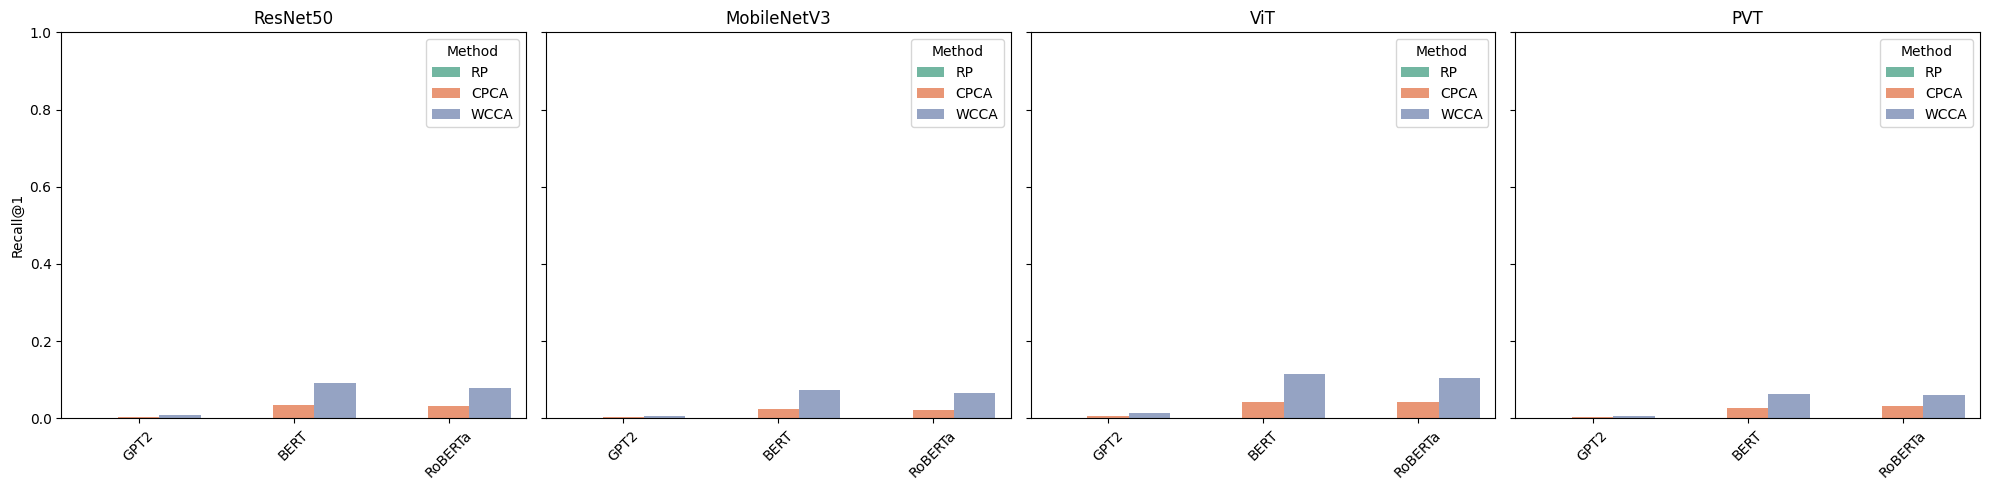

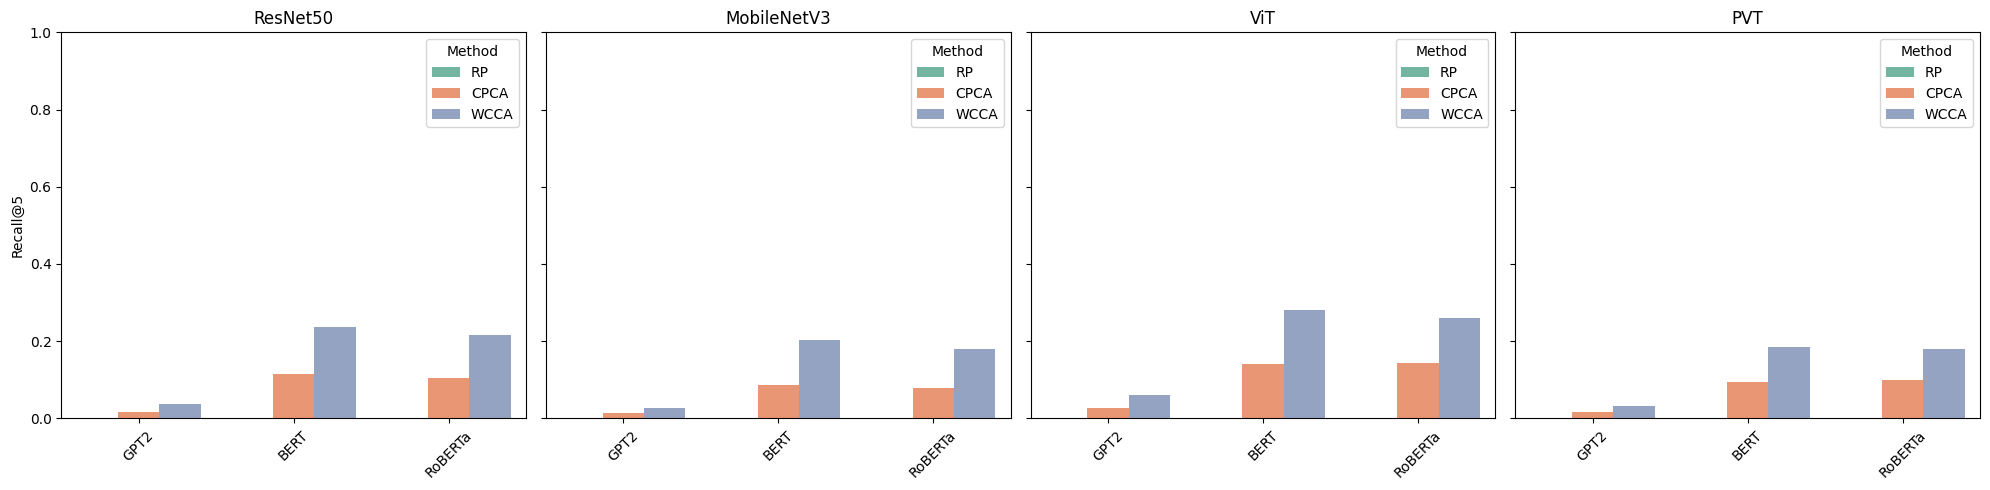

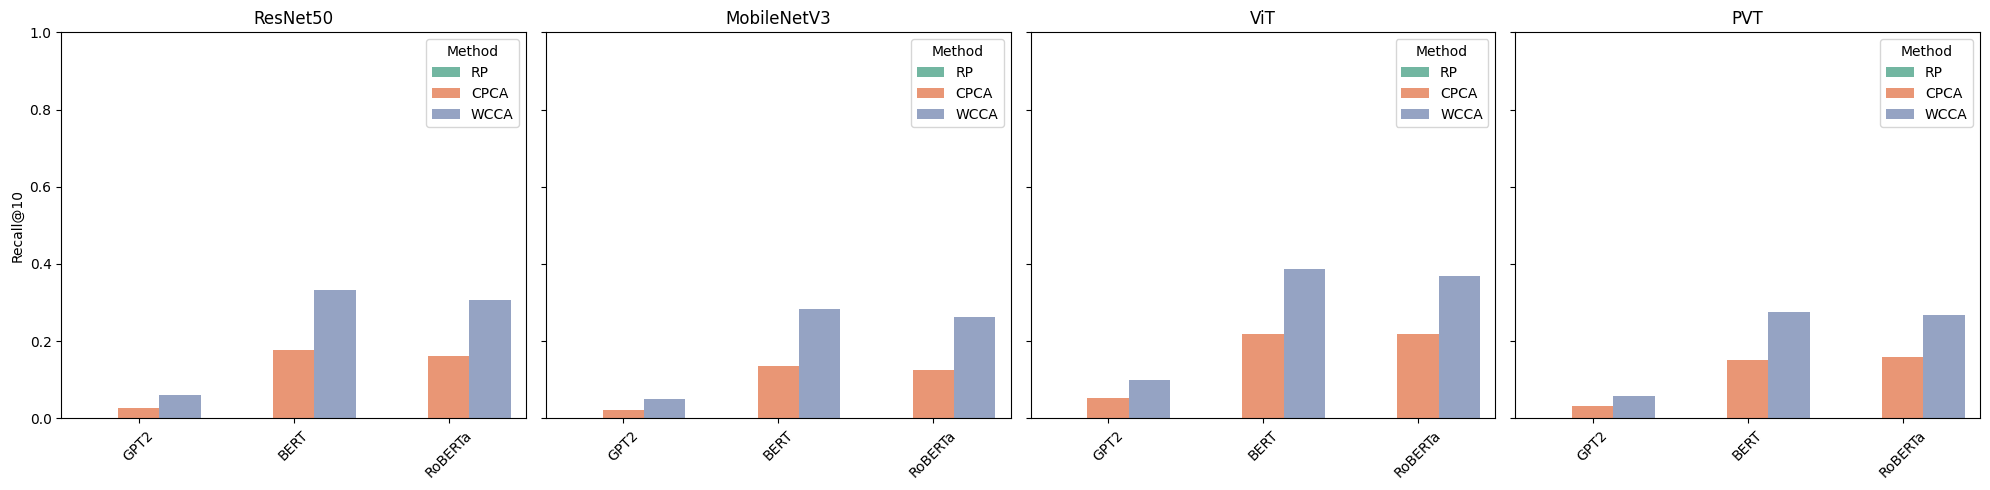

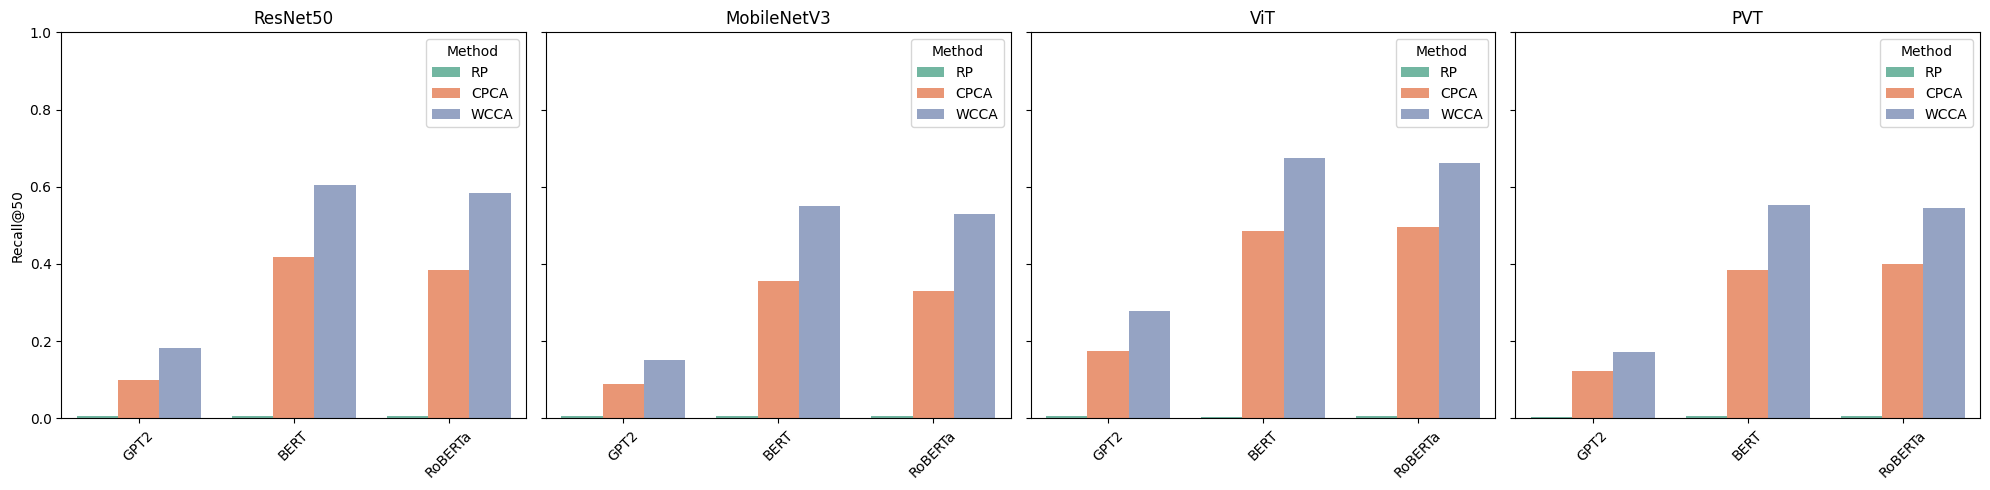

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_unimodal_projection_subplots(df, k):
    vision_models = df["Vision"].unique()[:4]
    n = len(vision_models)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=True)
    #fig, axes = plt.subplots(2, 2, figsize=(15, 13), sharey=True)
    axes = axes.flatten()
    # Ensure axes is iterable even if n=1
    if n == 1:
        axes = [axes]

    # Sort projection methods for consistent coloring
    df["Method"] = pd.Categorical(df["Method"], categories=["RP", "CPCA", "WCCA"], ordered=True)

    for ax, vision in zip(axes, vision_models):
        df_v = df[df["Vision"] == vision]

        sns.barplot(
            data=df_v,
            x="Text",
            y=f"R@{k}",
            hue="Method",
            palette="Set2",
            ax=ax
        )

        ax.set_ylim(0, 1)
        ax.set_title(f"{vision}")
        ax.set_xlabel("")
        ax.set_ylabel(f"Recall@{k}")
        ax.tick_params(axis='x', rotation=45)

    handles, labels = axes[0].get_legend_handles_labels()

    plt.tight_layout()
    plt.show()

# Run it
plot_unimodal_projection_subplots(df_uni_perf, 1)
plot_unimodal_projection_subplots(df_uni_perf, 5)
plot_unimodal_projection_subplots(df_uni_perf, 10)
plot_unimodal_projection_subplots(df_uni_perf, 50)


/tmp/ipykernel_580863/2432069270.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(
/tmp/ipykernel_580863/2432069270.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(


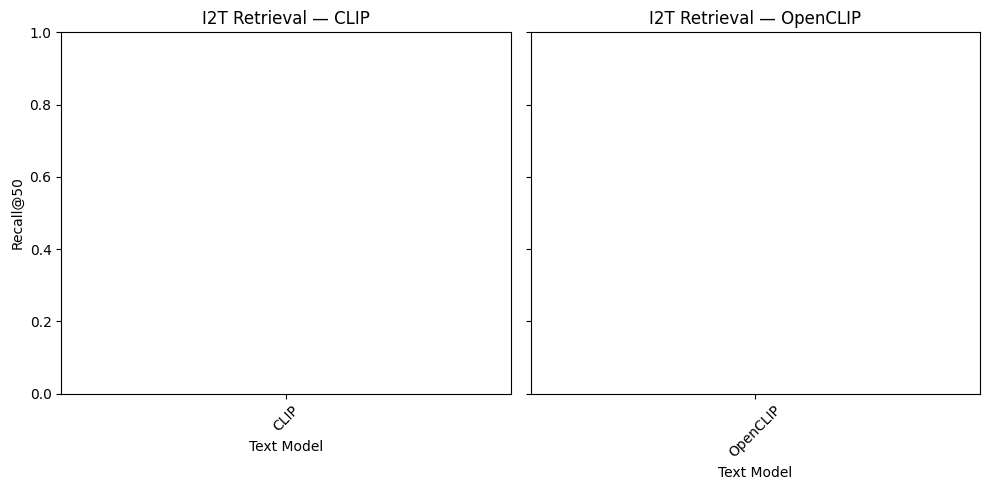

In [25]:
def plot_sota(df):
    sota_models = ["CLIP", "OpenCLIP"]
    df_sota = df[df["Vision"].isin(sota_models)].copy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    for ax, vision in zip(axes, sota_models):
        df_v = df_sota[df_sota["Vision"] == vision]

        sns.barplot(
            data=df_v,
            x="Text",
            y="R@50",
            hue="Method",
            palette={"SOTA": "#e78ac3"},
            ax=ax
        )

        ax.set_title(f"I2T Retrieval — {vision}")
        ax.set_xlabel("Text Model")
        ax.set_ylabel("Recall@50")
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

plot_sota(df_uni_perf)


In [26]:
def inject_sota_baseline_i2t(df):
    df = df.copy()

    # Extract CLIP as the baseline
    sota = df[(df["Vision"] == "CLIP") & (df["Method"] == "SOTA")].iloc[0]

    new_rows = []
    for vision in ["ResNet50", "MobileNetV3", "ViT", "PVT"]:
        for text in ["GPT2", "BERT", "RoBERTa"]:
            new_rows.append({
                "Vision": vision,
                "Text": text,
                "Method": "SOTA",
                "R@1": sota["R@1"],
                "R@5": sota["R@5"],
                "R@10": sota["R@10"],
                "R@50": sota["R@50"],
            })

    return pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

def inject_sota_baseline_t2i(df):
    df = df.copy()

    # Extract CLIP as the baseline
    sota = df[(df["Vision"] == "CLIP") & (df["Method"] == "SOTA")].iloc[1]

    new_rows = []
    for vision in ["ResNet50", "MobileNetV3", "ViT", "PVT"]:
        for text in ["GPT2", "BERT", "RoBERTa"]:
            new_rows.append({
                "Vision": vision,
                "Text": text,
                "Method": "SOTA",
                "R@1": sota["R@1"],
                "R@5": sota["R@5"],
                "R@10": sota["R@10"],
                "R@50": sota["R@50"],
            })

    return pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)


def plot_unimodal_with_sota(df):
    df = df.copy()

    # Ensure consistent ordering
    df["Method"] = pd.Categorical(
        df["Method"],
        categories=["RP", "CPCA", "WCCA", "SOTA"],
        ordered=True
    )

    vision_models = ["ResNet50", "MobileNetV3", "ViT", "PVT"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

    palette = {
        "RP": "#66c2a5",
        "CPCA": "#fc8d62",
        "WCCA": "#8da0cb",
        "SOTA": "#e78ac3"
    }

    for ax, vision in zip(axes, vision_models):
        df_v = df[df["Vision"] == vision]

        sns.barplot(
            data=df_v,
            x="Text",
            y="R@50",
            hue="Method",
            palette=palette,
            ax=ax
        )

        ax.set_title(f"I2T Retrieval — {vision}")
        ax.set_xlabel("Text Model")
        ax.set_ylabel("Recall@5")
        ax.tick_params(axis='x', rotation=45)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Method", loc="upper center", ncol=4)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
 

df_with_sota_i2t = inject_sota_baseline_i2t(df_all)
#plot_unimodal_with_sota(df_with_sota)
#plot_with_broken_axis(df_with_sota)
plot_axis_zoom(df_with_sota_i2t)
#plot_axis_zoom_under(df_with_sota)

IndexError: single positional indexer is out-of-bounds

/tmp/ipykernel_490076/3323897705.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


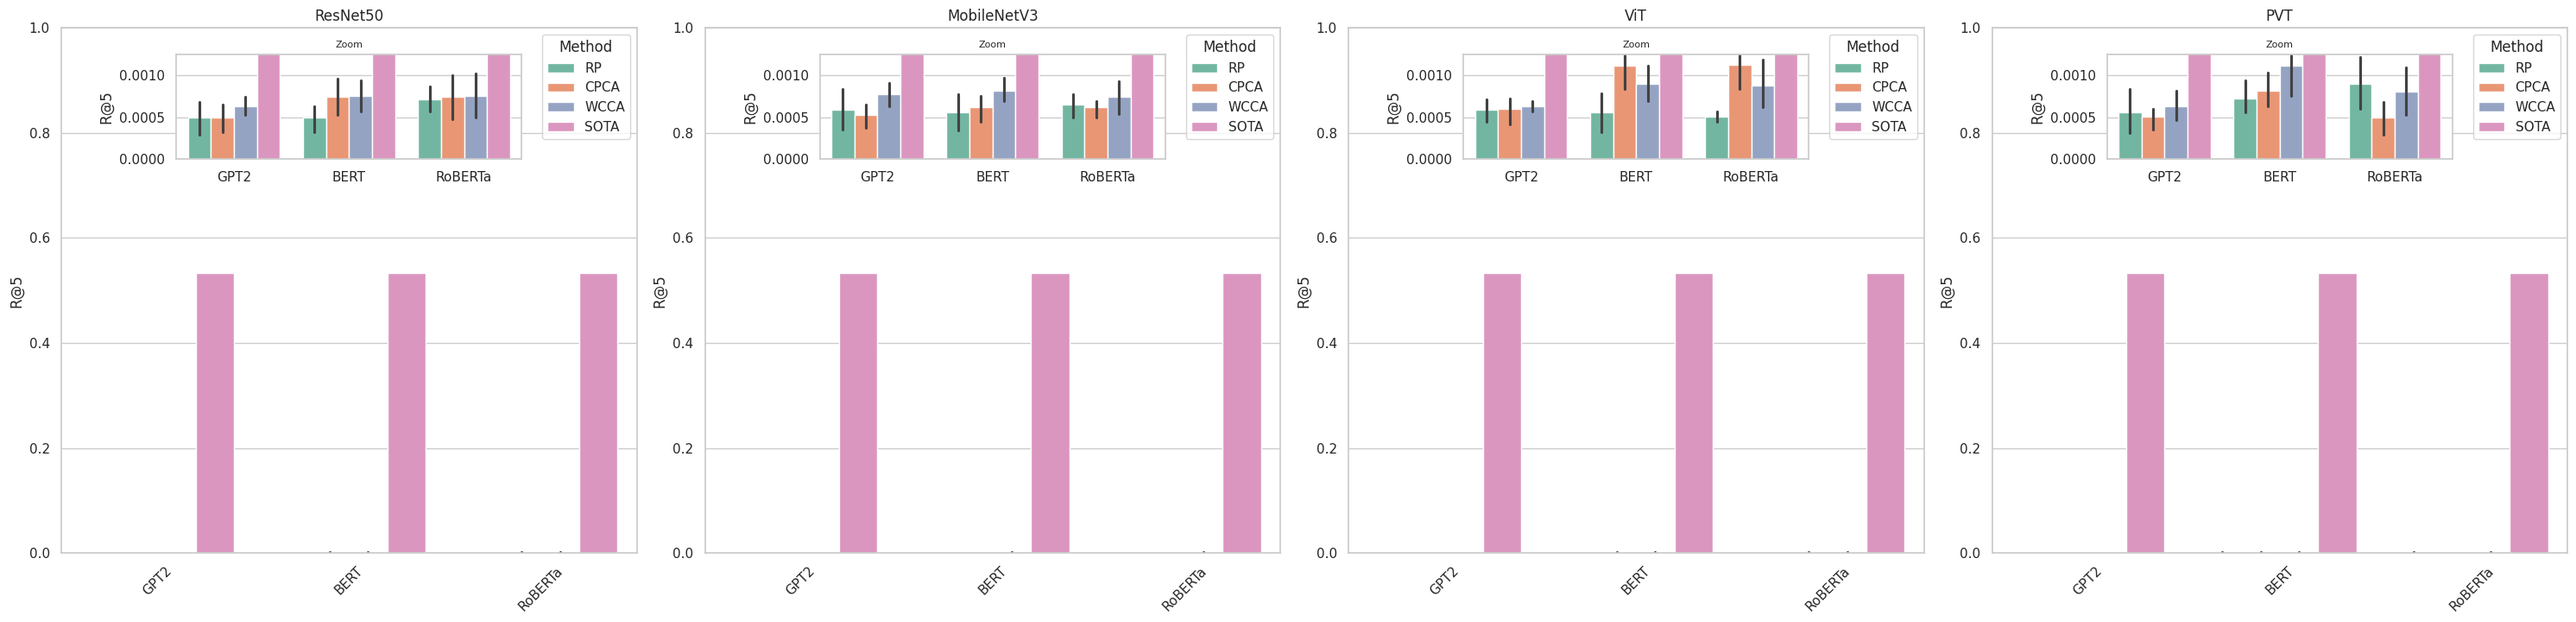

In [ ]:
df_with_sota_t2i = inject_sota_baseline_t2i(df_all)
#plot_unimodal_with_sota(df_with_sota)
#plot_with_broken_axis(df_with_sota)
plot_axis_zoom(df_with_sota_t2i)
#plot_axis_zoom_under(df_with_sota)

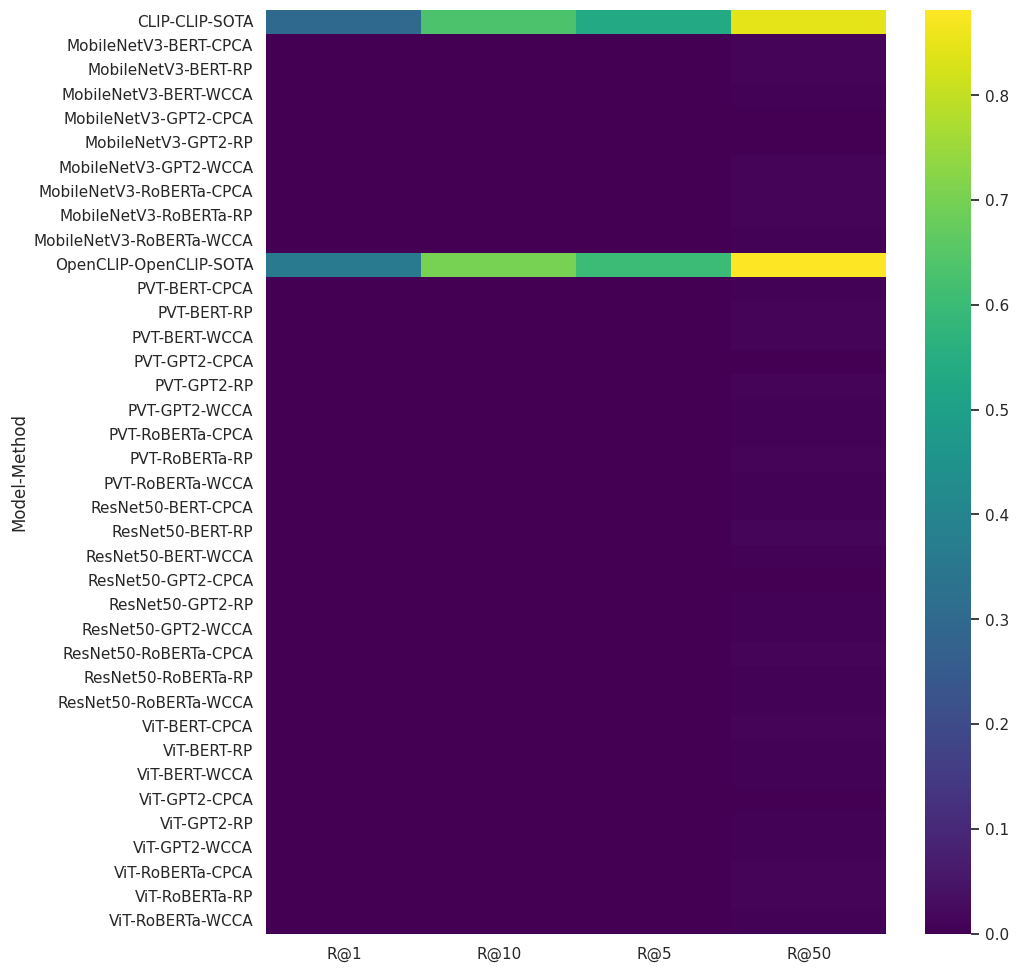

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_uni_perf.copy()

df["Model"] = df["Vision"] + "-" + df["Text"]

pivot = df.pivot_table(
    index=["Model", "Method"],
    values=["R@1", "R@5", "R@10", "R@50"]
)

plt.figure(figsize=(10, 12))
sns.heatmap(pivot, annot=False, cmap="viridis")
plt.show()

In [ ]:
uni_perf_cols = ["Vision", "Text", "Method", "Task", "R@1", "R@5", "R@10", "R@50"]

df_uni_perf = df_all[uni_perf_cols].copy()
df_uni_perf = df_uni_perf[df_uni_perf["Task"].isin(["T2I"])].copy()
df_uni_perf.drop(columns="Task").sort_values("R@5", ascending = False)[:10]

,Vision,Text,Method,R@1,R@5,R@10,R@50
297,OpenCLIP,OpenCLIP,SOTA,0.361241,0.602694,0.699320,0.881745
289,CLIP,CLIP,SOTA,0.298233,0.533086,0.632802,0.843950
265,PVT,RoBERTa,RP,0.000000,0.001730,0.002101,0.007045
177,ViT,BERT,CPCA,0.000371,0.001483,0.002719,0.009764
201,ViT,RoBERTa,CPCA,0.000000,0.001236,0.002348,0.008281
89,MobileNetV3,GPT2,WCCA,0.000494,0.001112,0.001730,0.007292
137,MobileNetV3,RoBERTa,WCCA,0.000494,0.001112,0.001607,0.006180
105,MobileNetV3,BERT,CPCA,0.000124,0.000989,0.001607,0.008281
113,MobileNetV3,BERT,WCCA,0.000000,0.000865,0.000989,0.004573
129,MobileNetV3,RoBERTa,CPCA,0.000000,0.000742,0.001112,0.008899


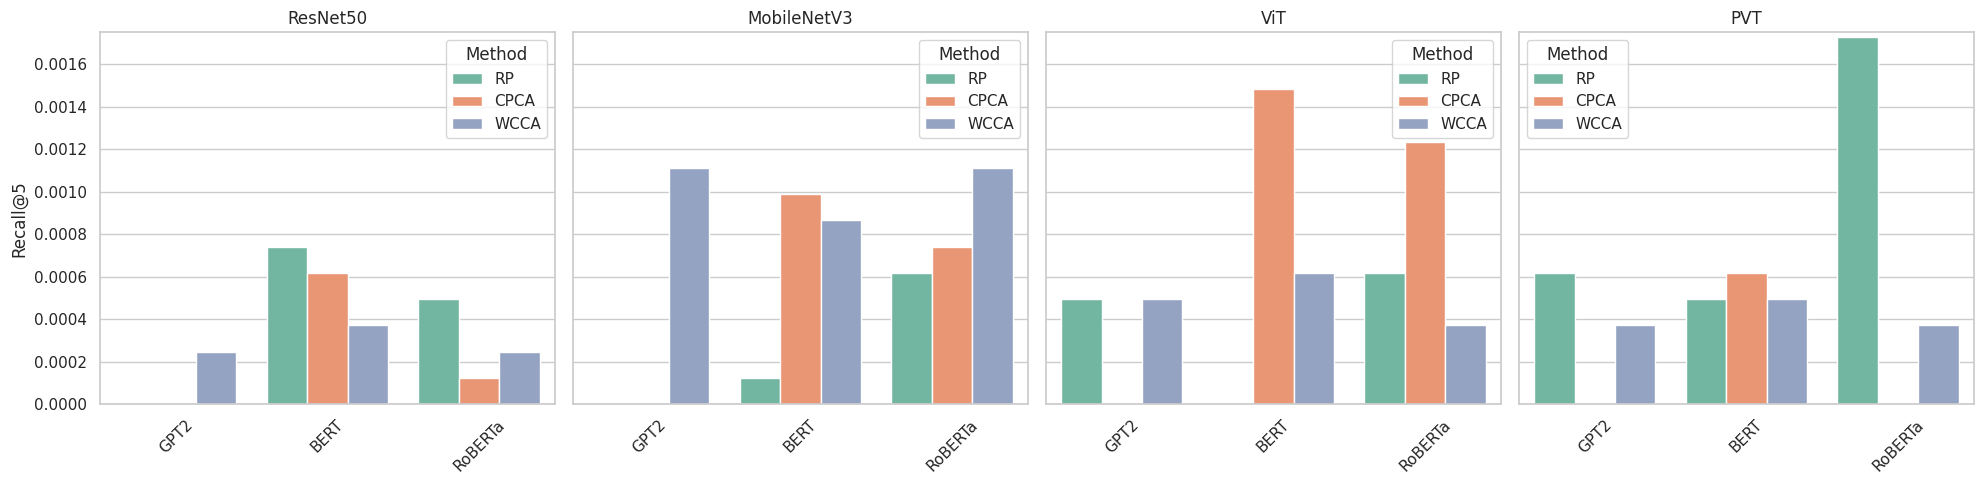

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_unimodal_projection_subplots(df, k):
    vision_models = df["Vision"].unique()[:4]
    n = len(vision_models)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=True)
    #fig, axes = plt.subplots(2, 2, figsize=(15, 13), sharey=True)
    axes = axes.flatten()
    # Ensure axes is iterable even if n=1
    if n == 1:
        axes = [axes]

    # Sort projection methods for consistent coloring
    df["Method"] = pd.Categorical(df["Method"], categories=["RP", "CPCA", "WCCA"], ordered=True)

    for ax, vision in zip(axes, vision_models):
        df_v = df[df["Vision"] == vision]

        sns.barplot(
            data=df_v,
            x="Text",
            y=f"R@{k}",
            hue="Method",
            palette="Set2",
            ax=ax
        )

        ax.set_ylim(0, 0.00175)
        ax.set_title(f"{vision}")
        ax.set_xlabel("")
        ax.set_ylabel(f"Recall@{k}")
        ax.tick_params(axis='x', rotation=45)

    handles, labels = axes[0].get_legend_handles_labels()

    plt.tight_layout()
    plt.show()

# Run it
#plot_unimodal_projection_subplots(df_uni_perf, 1)
plot_unimodal_projection_subplots(df_uni_perf, 5)
#plot_unimodal_projection_subplots(df_uni_perf, 10)
#plot_unimodal_projection_subplots(df_uni_perf, 50)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_axis_zoom(df):
    df = df.copy()
    df["Method"] = pd.Categorical(df["Method"], ["RP","CPCA","WCCA","SOTA"])

    vision_models = ["ResNet50","MobileNetV3","ViT","PVT"]

    fig, axes = plt.subplots(1, 4, figsize=(30,8), sharey=False)

    #fig, axes = plt.subplots(2, 2, figsize=(15,13), sharey=False)
    axes = axes.flatten()
    palette = {
        "RP": "#66c2a5",
        "CPCA": "#fc8d62",
        "WCCA": "#8da0cb",
        "SOTA": "#e78ac3"
    }

    for ax, vision in zip(axes, vision_models):
        df_v = df[df["Vision"] == vision]

        # Main plot (full scale)
        sns.barplot(
            data=df_v, x="Text", y="R@5",
            hue="Method", palette=palette, ax=ax
        )
        ax.set_xlabel("")
        ax.set_ylim(0, 1.0)
        ax.set_title(vision)
        ax.tick_params(axis='x', rotation=45)

        # Zoomed inset
        axins = inset_axes(ax, width="60%", height="20%", loc="upper center", borderpad=2)
        sns.barplot(
            data=df_v, x="Text", y="R@5",
            hue="Method", palette=palette, ax=axins
        )
        
        axins.set_xlabel("")

        axins.set_ylim(0, 0.00125)
        axins.tick_params(axis='x', rotation=0)
        #axins.set_yticks([0, 0.005, 0.001])
        axins.set_title("Zoom", fontsize=8)

        # Remove duplicate legends inside inset
        axins.get_legend().remove()

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

In [ ]:
multi_perf_cols = ["Vision", "Text", "Method", "Fusion", "Task", "R@1", "R@5", "R@10", "R@50"]

df_multi_perf = df_all[multi_perf_cols].copy()
df_multi_perf = df_multi_perf[df_multi_perf["Task"].isin(["M2T", "M2I"])].copy()
df_multi_perf

,Vision,Text,Method,Fusion,Task,R@1,R@5,R@10,R@50
2,ResNet50,GPT2,RP,ADD,M2T,0.000124,0.000618,0.001360,0.004202
3,ResNet50,GPT2,RP,ADD,M2I,0.000000,0.000494,0.001236,0.006056
4,ResNet50,GPT2,RP,GATED,M2T,0.000124,0.000618,0.001360,0.004202
5,ResNet50,GPT2,RP,GATED,M2I,0.000000,0.000494,0.001236,0.006056
6,ResNet50,GPT2,RP,MUL,M2T,0.000000,0.000989,0.001483,0.007045
...,...,...,...,...,...,...,...,...,...
299,OpenCLIP,OpenCLIP,SOTA,GATED,M2T,0.000124,0.000742,0.001483,0.007786
300,OpenCLIP,OpenCLIP,SOTA,MUL,M2T,0.000371,0.000742,0.001236,0.006550
301,OpenCLIP,OpenCLIP,SOTA,ADD,M2I,0.000124,0.001236,0.001730,0.006427
302,OpenCLIP,OpenCLIP,SOTA,GATED,M2I,0.000124,0.001236,0.001730,0.006427


In [49]:
multi_perf_cols = ["Vision", "Text", "Method", "Fusion", "Task", "R@1", "R@5", "R@10", "R@50"]

df_multi_perf = df_all[multi_perf_cols].copy()
df_multi_perf = df_multi_perf[df_multi_perf["Task"].isin(["M2T"])].copy()
df_multi_perf.drop(columns = "Task").sort_values("R@5", ascending = False)

,Vision,Text,Method,Fusion,R@1,R@5,R@10,R@50
299,OpenCLIP,OpenCLIP,sota,GATED,0.853788,0.965146,0.987023,0.999753
298,OpenCLIP,OpenCLIP,sota,ADD,0.853788,0.965146,0.987023,0.999753
290,CLIP,CLIP,sota,ADD,0.820294,0.956495,0.981090,0.999135
291,CLIP,CLIP,sota,GATED,0.820294,0.956495,0.981090,0.999135
188,ViT,BERT,WCCA,GATED,0.632802,0.858608,0.914844,0.986405
...,...,...,...,...,...,...,...,...
190,ViT,BERT,WCCA,MUL,0.000124,0.000371,0.001112,0.006427
238,PVT,GPT2,WCCA,MUL,0.000124,0.000371,0.000989,0.006303
230,PVT,GPT2,CPCA,MUL,0.000000,0.000371,0.001360,0.007910
158,ViT,GPT2,CPCA,MUL,0.000000,0.000247,0.000371,0.002966


In [50]:
multi_perf_cols = ["Vision", "Text", "Method", "Fusion", "Task", "R@1", "R@5", "R@10", "R@50"]

df_multi_perf = df_all[multi_perf_cols].copy()
df_multi_perf = df_multi_perf[df_multi_perf["Task"].isin(["M2I"])].copy()
df_multi_perf.drop(columns = "Task").sort_values("R@5", ascending = False)

,Vision,Text,Method,Fusion,R@1,R@5,R@10,R@50
302,OpenCLIP,OpenCLIP,sota,GATED,0.000124,0.001236,0.001730,0.006427
301,OpenCLIP,OpenCLIP,sota,ADD,0.000124,0.001236,0.001730,0.006427
55,ResNet50,RoBERTa,RP,MUL,0.000247,0.001112,0.002101,0.005685
205,ViT,RoBERTa,CPCA,GATED,0.000124,0.001112,0.002101,0.008034
203,ViT,RoBERTa,CPCA,ADD,0.000124,0.001112,0.002101,0.008034
...,...,...,...,...,...,...,...,...
63,ResNet50,RoBERTa,CPCA,MUL,0.000124,0.000247,0.000494,0.005809
7,ResNet50,GPT2,RP,MUL,0.000000,0.000124,0.000247,0.005438
111,MobileNetV3,BERT,CPCA,MUL,0.000124,0.000124,0.000989,0.006921
29,ResNet50,BERT,RP,GATED,0.000124,0.000124,0.001112,0.004944


In [ ]:
eff_cols = ["Vision", "Text", "Method", "Fusion", "Task", "Latency_s", "Throughput", "Memory_MB"]

df_eff = df_all[eff_cols].copy()

df_eff

,Vision,Text,Method,Fusion,Task,Latency_s,Throughput,Memory_MB
0,ResNet50,GPT2,RP,-,I2T,1.462692,44988.776261,16.570368
1,ResNet50,GPT2,RP,-,T2I,1.792247,37539.741112,16.570368
2,ResNet50,GPT2,RP,ADD,M2T,1.468791,45076.200871,16.570368
3,ResNet50,GPT2,RP,ADD,M2I,1.787404,46295.541892,16.570368
4,ResNet50,GPT2,RP,GATED,M2T,1.461936,44159.128563,16.570368
...,...,...,...,...,...,...,...,...
299,OpenCLIP,OpenCLIP,SOTA,GATED,M2T,1.694007,18612.948211,49.711104
300,OpenCLIP,OpenCLIP,SOTA,MUL,M2T,1.499985,18425.184946,49.711104
301,OpenCLIP,OpenCLIP,SOTA,ADD,M2I,1.492615,18273.556237,49.711104
302,OpenCLIP,OpenCLIP,SOTA,GATED,M2I,1.498313,17573.135017,49.711104


In [36]:
uni_eff_cols = ["Vision", "Text", "Method", "Task", "Latency_s", "Throughput", "Memory_MB"]

df_uni_eff = df_all[uni_eff_cols].copy()
df_uni_eff = df_uni_eff[df_uni_eff["Task"].isin(["I2T", "T2I"])].copy()
df_uni_eff

,Vision,Text,Method,Task,Latency_s,Throughput,Memory_MB
0,ResNet50,GPT2,RP,I2T,7.957567,3057.326267,49.711104
1,ResNet50,GPT2,RP,T2I,8.917310,45790.901955,49.711104
8,ResNet50,GPT2,CPCA,I2T,6.824750,6269.403831,24.855552
9,ResNet50,GPT2,CPCA,T2I,7.856241,92036.777877,24.855552
16,ResNet50,GPT2,WCCA,I2T,6.814996,6414.694482,24.855552
...,...,...,...,...,...,...,...
281,PVT,RoBERTa,WCCA,T2I,7.859359,85208.469959,24.855552
288,CLIP,CLIP,sota,I2T,7.080019,3249.901689,99.422208
289,CLIP,CLIP,sota,T2I,8.118604,26236.705740,99.422208
296,OpenCLIP,OpenCLIP,sota,I2T,7.288818,2391.867063,149.133312


In [41]:
import numpy as np
import pandas as pd

# -----------------------------
# Metric direction (same as before)
# -----------------------------
METRIC_DIRECTION = {
    "Latency_s": "low",
    "Throughput": "high",
    "Memory_MB": "low",
}

# -----------------------------
# Soft normalization (same as before)
# -----------------------------
def soft_normalize(df):

    df_norm = df.copy()

    for col in df.columns:

        if col in ["Vision", "Text", "Method", "Fusion", "Task"]:
            continue

        x = df[col].astype(float)

        # flip sign if lower is better
        if METRIC_DIRECTION.get(col, "high") == "low":
            x = -x

        # z-score + sigmoid
        z = (x - x.mean()) / (x.std() + 1e-8)
        df_norm[col] = 1 / (1 + np.exp(-z))

    return df_norm

# -----------------------------
# Average normalization (same as before)
# -----------------------------
def avg_normalize(df, columns):
    df_norm = df.copy()
    for col in columns:
        s = df_norm[col].sum()
        if s == 0:
            df_norm[col] = 0
        else:
            df_norm[col] = df_norm[col] / s
    return df_norm

# -----------------------------
# Compute efficiency score
# -----------------------------
def compute_efficiency_score(df):

    df["Score"] = (
        0.33 * (1 - df["Latency_s"]) +
        0.33 * df["Throughput"] +
        0.33 * (1 - df["Memory_MB"])
    )

    return df

# -----------------------------
# APPLY TO YOUR DATA
# -----------------------------
# Filter to I2T only
df_uni_eff = df_all[["Vision", "Text", "Method", "Task", 
                     "Latency_s", "Throughput", "Memory_MB"]].copy()

df_uni_eff = df_uni_eff[df_uni_eff["Task"] == "I2T"].reset_index(drop=True)

# Normalize
df_soft = soft_normalize(df_uni_eff)
df_avg  = avg_normalize(df_soft, ["Latency_s", "Throughput", "Memory_MB"])

# Compute score
df_scored = compute_efficiency_score(df_avg)

# Sort by score
df_sorted = df_scored.sort_values("Score", ascending=False)

# Show top 10
df_sorted.drop(columns = "Task")


,Vision,Text,Method,Latency_s,Throughput,Memory_MB,Score
12,MobileNetV3,BERT,RP,0.008309,0.011493,0.019251,0.654698
37,OpenCLIP,OpenCLIP,sota,0.024074,0.007895,0.000518,0.654490
33,PVT,RoBERTa,RP,0.009479,0.011693,0.019251,0.654378
21,ViT,BERT,RP,0.009891,0.011437,0.019251,0.654158
18,ViT,GPT2,RP,0.009998,0.011544,0.019251,0.654157
6,ResNet50,RoBERTa,RP,0.009958,0.011496,0.019251,0.654155
24,ViT,RoBERTa,RP,0.009935,0.011427,0.019251,0.654140
30,PVT,BERT,RP,0.010403,0.011651,0.019251,0.654059
15,MobileNetV3,RoBERTa,RP,0.010245,0.011491,0.019251,0.654059
9,MobileNetV3,GPT2,RP,0.010219,0.011443,0.019251,0.654051


In [ ]:
# Filter to T2I only
df_uni_eff = df_all[["Vision", "Text", "Method", "Task", 
                     "Latency_s", "Throughput", "Memory_MB"]].copy()

df_uni_eff = df_uni_eff[df_uni_eff["Task"] == "T2I"].reset_index(drop=True)

# Normalize
df_soft = soft_normalize(df_uni_eff)
df_avg  = avg_normalize(df_soft, ["Latency_s", "Throughput", "Memory_MB"])

# Compute score
df_scored = compute_efficiency_score(df_avg)

# Sort by score
df_sorted = df_scored.sort_values("Score", ascending=False)

# Show top 10
df_sorted.drop(columns = "Task")[:10]

,Vision,Text,Method,Latency_s,Throughput,Memory_MB,Score
36,CLIP,CLIP,SOTA,0.000801,0.008086,0.002141,0.661698
37,OpenCLIP,OpenCLIP,SOTA,0.000721,0.005919,0.000342,0.661602
14,MobileNetV3,BERT,WCCA,0.026663,0.035878,0.028994,0.653473
29,PVT,GPT2,WCCA,0.026710,0.035844,0.028994,0.653446
22,ViT,BERT,CPCA,0.028453,0.035988,0.028994,0.652919
7,ResNet50,RoBERTa,CPCA,0.028265,0.035784,0.028994,0.652913
35,PVT,RoBERTa,WCCA,0.028476,0.035936,0.028994,0.652894
26,ViT,RoBERTa,WCCA,0.028423,0.035769,0.028994,0.652856
10,MobileNetV3,GPT2,CPCA,0.028636,0.035960,0.028994,0.652849
32,PVT,BERT,WCCA,0.028369,0.035683,0.028994,0.652846


In [ ]:
df_uni_eff = df_all[["Vision", "Text", "Method", "Task", 
                     "Latency_s", "Throughput", "Memory_MB"]].copy()

df_uni_eff = df_uni_eff[df_uni_eff["Task"].isin(["I2T", "T2I"])].reset_index(drop=True)

# Normalize
df_soft = soft_normalize(df_uni_eff)
df_avg  = avg_normalize(df_soft, ["Latency_s", "Throughput", "Memory_MB"])

# Compute score
df_scored = compute_efficiency_score(df_avg)

# Sort by score
df_sorted = df_scored.sort_values("Score", ascending=False)

# Show top 10
df_sorted[:10]

In [ ]:
multi_eff_cols = ["Vision", "Text", "Method", "Fusion", "Task", "Latency_s", "Throughput", "Memory_MB"]

df_multi_eff = df_all[multi_eff_cols].copy()
df_multi_eff = df_multi_eff[df_multi_eff["Task"].isin(["M2T", "M2I"])].copy()
df_multi_eff

In [55]:
multi_eff_cols = ["Vision", "Text", "Method", "Fusion", "Task", "Latency_s", "Throughput", "Memory_MB"]

df_multi_eff = df_all[multi_eff_cols].copy()
df_multi_eff = df_multi_eff[df_multi_eff["Task"].isin(["M2T"])].copy()


# Normalize
df_soft = soft_normalize(df_multi_eff)
df_avg  = avg_normalize(df_soft, ["Latency_s", "Throughput", "Memory_MB"])

# Compute score
df_scored = compute_efficiency_score(df_avg)

# Sort by score
df_sorted = df_scored.sort_values("Score", ascending=False)


# Show top 10
df_sorted.drop(columns = "Task")

,Vision,Text,Method,Fusion,Latency_s,Throughput,Memory_MB,Score
300,OpenCLIP,OpenCLIP,sota,MUL,0.007900,0.003857,0.000166,0.658611
298,OpenCLIP,OpenCLIP,sota,ADD,0.007639,0.002617,0.000166,0.658288
299,OpenCLIP,OpenCLIP,sota,GATED,0.007818,0.002644,0.000166,0.658238
52,ResNet50,RoBERTa,RP,GATED,0.002722,0.003711,0.006396,0.658216
28,ResNet50,BERT,RP,GATED,0.002733,0.003721,0.006396,0.658215
...,...,...,...,...,...,...,...,...
274,PVT,RoBERTa,CPCA,ADD,0.011663,0.011468,0.010633,0.656427
254,PVT,BERT,CPCA,MUL,0.011590,0.011369,0.010633,0.656418
276,PVT,RoBERTa,CPCA,GATED,0.011608,0.011387,0.010633,0.656418
230,PVT,GPT2,CPCA,MUL,0.011746,0.011523,0.010633,0.656418


In [42]:
multi_eff_cols = ["Vision", "Text", "Method", "Fusion", "Task", "Latency_s", "Throughput", "Memory_MB"]

df_multi_eff = df_all[multi_eff_cols].copy()
df_multi_eff = df_multi_eff[df_multi_eff["Task"].isin(["M2I"])].copy()


# Normalize
df_soft = soft_normalize(df_multi_eff)
df_avg  = avg_normalize(df_soft, ["Latency_s", "Throughput", "Memory_MB"])

# Compute score
df_scored = compute_efficiency_score(df_avg)

# Sort by score
df_sorted = df_scored.sort_values("Score", ascending=False)


# Show top 10
df_sorted.drop(columns = "Task")[:10]

,Vision,Text,Method,Fusion,Latency_s,Throughput,Memory_MB,Score
303,OpenCLIP,OpenCLIP,sota,MUL,0.004290,0.001544,0.000166,0.659039
75,MobileNetV3,GPT2,RP,ADD,0.001712,0.004287,0.006396,0.658739
99,MobileNetV3,BERT,RP,ADD,0.001893,0.004297,0.006396,0.658683
247,PVT,BERT,RP,MUL,0.001819,0.004186,0.006396,0.658670
123,MobileNetV3,RoBERTa,RP,ADD,0.001994,0.004281,0.006396,0.658644
3,ResNet50,GPT2,RP,ADD,0.001850,0.004101,0.006396,0.658632
271,PVT,RoBERTa,RP,MUL,0.001868,0.004098,0.006396,0.658625
293,CLIP,CLIP,sota,ADD,0.005559,0.002144,0.001219,0.658471
125,MobileNetV3,RoBERTa,RP,GATED,0.003157,0.004279,0.006396,0.658260
5,ResNet50,GPT2,RP,GATED,0.003148,0.004269,0.006396,0.658259


In [ ]:
df_all.to_csv("/home/aysel/tfe/TFE_Data/Evaluations/Multimodal/all_retrieval_results.csv", index=False)
df_perf.to_csv("/home/aysel/tfe/TFE_Data/Evaluations/Multimodal/all_performance_results.csv", index=False)
df_eff.to_csv("/home/aysel/tfe/TFE_Data/Evaluations/Multimodal/all_efficiency_results.csv", index=False)
